   Year  Month  Day Weekend?    Hour Collision Type         Injury Type  \
0  2015      1    5  Weekday     0.0          2-Car   No injury/unknown   
1  2015      1    6  Weekday  1500.0          2-Car   No injury/unknown   
2  2015      1    6  Weekend  2300.0          2-Car  Non-incapacitating   
3  2015      1    7  Weekend   900.0          2-Car  Non-incapacitating   
4  2015      1    7  Weekend  1100.0          2-Car   No injury/unknown   

                          Primary Factor      Reported_Location   Latitude  \
0  OTHER (DRIVER) - EXPLAIN IN NARRATIVE             1ST & FESS  39.159207   
1                  FOLLOWING TOO CLOSELY          2ND & COLLEGE  39.161440   
2              DISREGARD SIGNAL/REG SIGN  BASSWOOD & BLOOMFIELD  39.149780   
3          FAILURE TO YIELD RIGHT OF WAY         GATES & JACOBS  39.165655   
4          FAILURE TO YIELD RIGHT OF WAY                  W 3RD  39.164848   

   Longitude  
0 -86.525874  
1 -86.534848  
2 -86.568890  
3 -86.575956  
4 -86

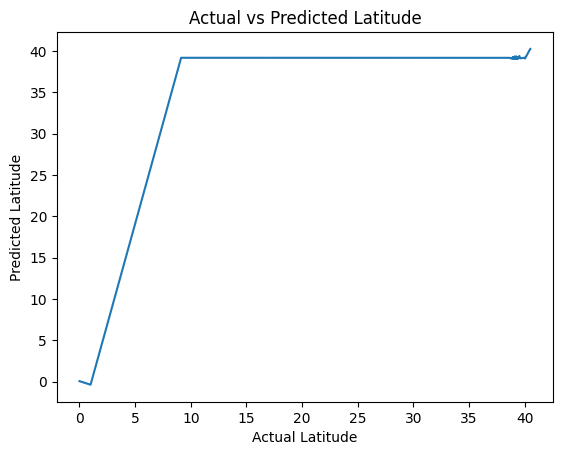

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Read the dataset
url = "https://raw.githubusercontent.com/ajay2712006/ds45/main/monroecountycarcrach2003-2015.csv"
df = pd.read_csv(url)

# Display first 5 rows
print(df.head())

# Remove rows with missing values
df = df.dropna()

# Remove the Reported_Location column
df = df.drop("Reported_Location", axis=1)

# Convert text columns into numbers
df = pd.get_dummies(df, drop_first=True)

# Select input (X) and output (y)
X = df.drop("Latitude", axis=1)
y = df["Latitude"]

# Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

# Scale the input data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict the test data
y_pred = model.predict(X_test)

# Show first 5 predictions
print("Predicted Values")
print(y_pred[:5])

# Compare Actual and Predicted values
result = pd.DataFrame({
    "Actual Latitude": y_test.values,
    "Predicted Latitude": y_pred
})

print(result.head())

# Draw a graph
sns.lineplot(x=y_test.values, y=y_pred)

plt.xlabel("Actual Latitude")
plt.ylabel("Predicted Latitude")
plt.title("Actual vs Predicted Latitude")

plt.show()